In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, erf
from scipy.optimize import brentq

In [3]:
# -----------------------------
# Load data
# -----------------------------
price_files = {
    0: "data/prices_round_3_day_0.csv",
    1: "data/prices_round_3_day_1.csv",
    2: "data/prices_round_3_day_2.csv",
}

dfs = []

for day, path in price_files.items():
    df = pd.read_csv(path, sep=";")
    df["day"] = day
    dfs.append(df)

prices = pd.concat(dfs, ignore_index=True)

prices["product"] = prices["product"].str.strip()

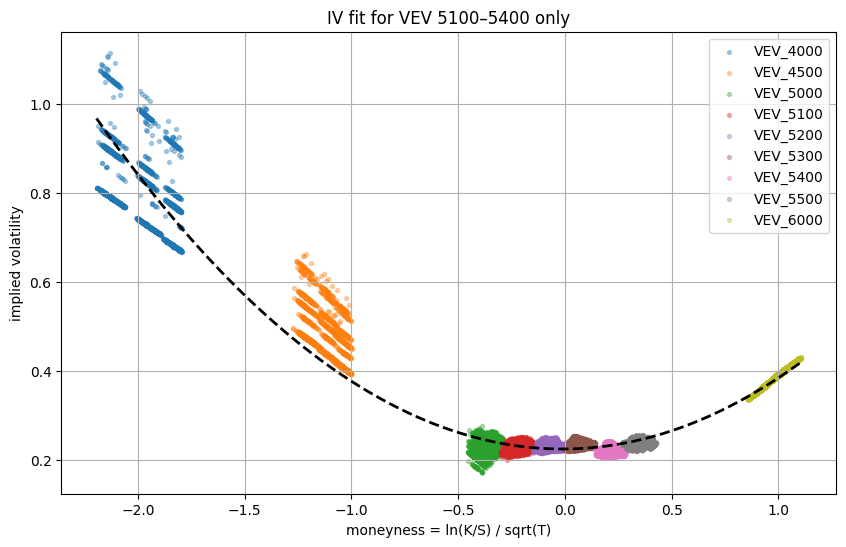

4th power coefficients:
a, b, c, d, e = [0.15575883 0.00389196 0.22529038]


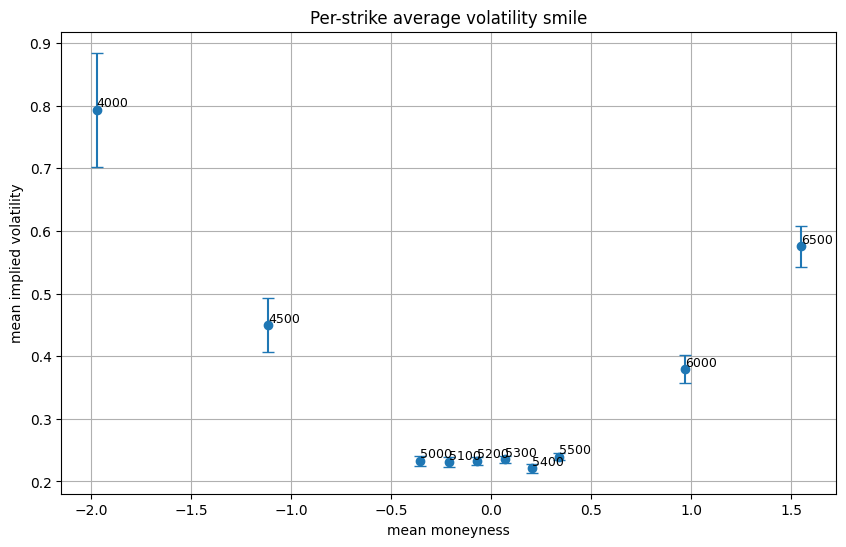

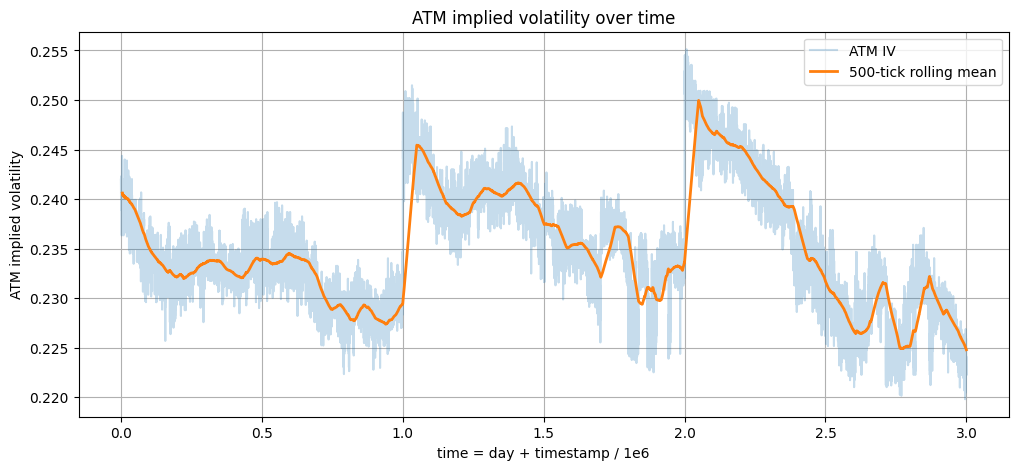

In [14]:
# -----------------------------
# Basic helpers
# -----------------------------
def norm_cdf(x):
    return 0.5 * (1 + erf(x / np.sqrt(2)))


def bs_call(S, K, T, sigma, r=0):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)


def implied_vol_call(price, S, K, T):
    intrinsic = max(S - K, 0)

    if price <= intrinsic:
        return np.nan

    try:
        return brentq(
            lambda sigma: bs_call(S, K, T, sigma) - price,
            1e-6,
            5.0,
            maxiter=100,
        )
    except:
        return np.nan


def get_strike(product):
    return int(product.split("_")[-1])


# -----------------------------
# Prepare underlying prices
# -----------------------------
underlying = prices[prices["product"] == "VELVETFRUIT_EXTRACT"][
    ["day", "timestamp", "mid_price"]
].rename(columns={"mid_price": "S"})

# -----------------------------
# Prepare voucher prices
# -----------------------------
vouchers = prices[prices["product"].str.startswith("VEV_")].copy()

vouchers["K"] = vouchers["product"].apply(get_strike)

# Historical TTE mapping:
# day 0 -> 8 days
# day 1 -> 7 days
# day 2 -> 6 days
vouchers["T_days"] = vouchers["day"].map({0: 8, 1: 7, 2: 6})
vouchers["T"] = vouchers["T_days"] / 365

# Merge with underlying
opt = vouchers.merge(underlying, on=["day", "timestamp"], how="left")

opt = opt.dropna(subset=["mid_price", "S", "K", "T"])

# -----------------------------
# Compute implied volatility
# -----------------------------
opt["iv"] = opt.apply(
    lambda row: implied_vol_call(
        price=row["mid_price"], S=row["S"], K=row["K"], T=row["T"]
    ),
    axis=1,
)

opt["moneyness"] = np.log(opt["K"] / opt["S"]) / np.sqrt(opt["T"])

opt_clean = opt.dropna(subset=["iv", "moneyness"]).copy()

# Optional: remove extreme / bad values
opt_clean = opt_clean[(opt_clean["iv"] > 0.01) & (opt_clean["iv"] < 3.0)]

# -----------------------------
# Plot 1: all ticks smile
# -----------------------------
# Only fit/use strikes 5100–5400
fit_data = opt_clean[opt_clean["K"].between(4000, 6000)].copy()

x = fit_data["moneyness"].to_numpy()
y = fit_data["iv"].to_numpy()

coef4 = np.polyfit(x, y, deg=2)

x_grid = np.linspace(x.min(), x.max(), 300)
y_fit = np.polyval(coef4, x_grid)

plt.figure(figsize=(10, 6))

for K in sorted(fit_data["K"].unique()):
    sub = fit_data[fit_data["K"] == K]
    plt.scatter(sub["moneyness"], sub["iv"], s=8, alpha=0.35, label=f"VEV_{K}")

plt.plot(
    x_grid,
    y_fit,
    linestyle="--",
    color="black",
    linewidth=2,
    # label=(
    #     f"4th fit: {coef4[0]:.4f}m⁴ + {coef4[1]:.4f}m³ "
    #     f"+ {coef4[2]:.4f}m² + {coef4[3]:.4f}m + {coef4[4]:.4f}"
    # ),
)

plt.xlabel("moneyness = ln(K/S) / sqrt(T)")
plt.ylabel("implied volatility")
plt.title("IV fit for VEV 5100–5400 only")
plt.legend()
plt.grid(True)
plt.show()

print("4th power coefficients:")
print("a, b, c, d, e =", coef4)
# -----------------------------
# Plot 2: per-strike average smile
# -----------------------------
strike_summary = (
    opt_clean.groupby("K")
    .agg(
        mean_moneyness=("moneyness", "mean"),
        mean_iv=("iv", "mean"),
        std_iv=("iv", "std"),
        count=("iv", "count"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    strike_summary["mean_moneyness"],
    strike_summary["mean_iv"],
    yerr=strike_summary["std_iv"],
    fmt="o",
    capsize=4,
)

for _, row in strike_summary.iterrows():
    plt.text(
        row["mean_moneyness"],
        row["mean_iv"],
        str(int(row["K"])),
        fontsize=9,
        ha="left",
        va="bottom",
    )

plt.xlabel("mean moneyness")
plt.ylabel("mean implied volatility")
plt.title("Per-strike average volatility smile")
plt.grid(True)
plt.show()

# -----------------------------
# Plot 3: ATM IV over time
# -----------------------------
# Pick closest-to-ATM voucher per timestamp
atm = (
    opt_clean.assign(abs_moneyness=lambda df: df["moneyness"].abs())
    .sort_values(["day", "timestamp", "abs_moneyness"])
    .groupby(["day", "timestamp"])
    .first()
    .reset_index()
)

atm["time"] = atm["day"] + atm["timestamp"] / 1_000_000
atm["iv_roll"] = atm["iv"].rolling(500, min_periods=50).mean()

plt.figure(figsize=(12, 5))
plt.plot(atm["time"], atm["iv"], alpha=0.25, label="ATM IV")
plt.plot(
    atm["time"], atm["iv_roll"], linewidth=2, label="500-tick rolling mean"
)

plt.xlabel("time = day + timestamp / 1e6")
plt.ylabel("ATM implied volatility")
plt.title("ATM implied volatility over time")
plt.legend()
plt.grid(True)
plt.show()